# Earthquake Classifier — 2D CNN on Spectrograms
Binary classification: earthquake (1) vs noise (0)
Input: 10×10 log-power spectrograms from `data/spectrograms/spectrograms_10x10.npy`

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import (
    f1_score, accuracy_score, precision_score, recall_score,
    roc_auc_score, confusion_matrix, classification_report,
    ConfusionMatrixDisplay, RocCurveDisplay,
)

DEVICE     = "cuda" if torch.cuda.is_available() else "cpu"
BATCH_SIZE = 256
EPOCHS     = 30
LR         = 1e-3
PATIENCE   = 5

print(f"Using device: {DEVICE}")

Using device: cpu


## Load & normalise data

In [16]:
X_spec = np.load("../data/spectrograms/spectrograms_10x10.npy")  # (N, 10, 10)
meta   = pd.read_csv("../data/metadata.csv", low_memory=False)

# Add channel dim → (N, 1, 10, 10) as required by Conv2d
X_spec = X_spec[:, np.newaxis, :, :]

# Normalise using training-set statistics only (avoids data leakage)
train_mask = (meta["split"] == "train").values
mu  = float(X_spec[train_mask].mean())
std = float(X_spec[train_mask].std())
X_spec = ((X_spec - mu) / (std + 1e-8)).astype(np.float32)

labels = meta["label"].values.astype(np.float32)

print(f"Spectrograms : {X_spec.shape}  dtype={X_spec.dtype}")
print(f"Earthquakes  : {(labels==1).sum():,}  |  Noise: {(labels==0).sum():,}")
print(f"Train / Val / Test : {train_mask.sum():,} / {(meta['split']=='val').sum():,} / {(meta['split']=='test').sum():,}")

Spectrograms : (427770, 1, 10, 10)  dtype=float32
Earthquakes  : 193,424  |  Noise: 234,346
Train / Val / Test : 256,691 / 64,158 / 106,921


## Dataset & DataLoaders

In [17]:
class SpectrogramDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.from_numpy(X)
        self.y = torch.from_numpy(y)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, i):
        return self.X[i], self.y[i]


def make_loader(split_name, shuffle=False):
    mask = (meta["split"] == split_name).values
    return DataLoader(
        SpectrogramDataset(X_spec[mask], labels[mask]),
        batch_size=BATCH_SIZE,
        shuffle=shuffle,
        num_workers=0,
        pin_memory=(DEVICE == "cuda"),
    )


train_loader = make_loader("train", shuffle=True)
val_loader   = make_loader("val")
test_loader  = make_loader("test")

print(f"Batches — Train: {len(train_loader)}  Val: {len(val_loader)}  Test: {len(test_loader)}")

Batches — Train: 1003  Val: 251  Test: 418


## Model — 2D CNN
Three conv blocks designed for a 10×10 input. AdaptiveAvgPool at the end collapses spatial dims safely regardless of exact size.

In [18]:
class EarthquakeCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            # Block 1: (1, 10, 10) → (32, 10, 10)
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            # Block 2: (32, 10, 10) → (64, 5, 5)
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),
            # Block 3: (64, 5, 5) → (128, 2, 2)
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),           # 128 * 2 * 2 = 512
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, 1),      # raw logit (BCEWithLogitsLoss handles sigmoid)
        )

    def forward(self, x):
        return self.classifier(self.features(x)).squeeze(1)


model = EarthquakeCNN().to(DEVICE)
print(model)
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}")

EarthquakeCNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (9): ReLU()
    (10): AdaptiveAvgPool2d(output_size=2)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=512, out_features=256, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.4, inplace=False)
    (4): Linear(in_features=256, out_features=1, bias=True)
  )
)

Total parameters: 224,705


## Training

In [19]:
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)
# Halve LR when val_loss plateaus for 3 epochs
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", patience=3, factor=0.5
)

history          = {"train_loss": [], "val_loss": [], "val_f1": []}
best_val_f1      = 0.0
patience_counter = 0
CKPT_PATH        = "best_model.pt"

try:
    for epoch in range(1, EPOCHS + 1):
        # ---- Train ----
        model.train()
        train_loss = 0.0
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(model(X_batch), y_batch)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * len(y_batch)
        train_loss /= len(train_loader.dataset)

        # ---- Validate ----
        model.eval()
        val_loss   = 0.0
        val_probs, val_true = [], []
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
                logits = model(X_batch)
                val_loss += criterion(logits, y_batch).item() * len(y_batch)
                val_probs.append(torch.sigmoid(logits).cpu().numpy())
                val_true.append(y_batch.cpu().numpy())
        val_loss  /= len(val_loader.dataset)
        val_probs  = np.concatenate(val_probs)
        val_true   = np.concatenate(val_true)
        val_preds  = (val_probs >= 0.5).astype(int)
        val_f1     = f1_score(val_true, val_preds)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_f1"].append(val_f1)

        scheduler.step(val_loss)

        print(f"Epoch {epoch:2d}/{EPOCHS}  "
              f"train_loss={train_loss:.4f}  "
              f"val_loss={val_loss:.4f}  "
              f"val_F1={val_f1:.4f}")

        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            torch.save(model.state_dict(), CKPT_PATH)
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= PATIENCE:
                print(f"Early stopping at epoch {epoch} (no val F1 improvement for {PATIENCE} epochs)")
                break

except KeyboardInterrupt:
    print(f"\nTraining stopped manually at epoch {epoch}.")

print(f"Best val F1: {best_val_f1:.4f}  —  checkpoint saved to {CKPT_PATH}")

Epoch  1/30  train_loss=0.0230  val_loss=0.0136  val_F1=0.9956
Epoch  2/30  train_loss=0.0134  val_loss=0.0119  val_F1=0.9959
Epoch  3/30  train_loss=0.0118  val_loss=0.0124  val_F1=0.9955
Epoch  4/30  train_loss=0.0105  val_loss=0.0102  val_F1=0.9961
Epoch  5/30  train_loss=0.0100  val_loss=0.0102  val_F1=0.9965
Epoch  6/30  train_loss=0.0097  val_loss=0.0129  val_F1=0.9952
Epoch  7/30  train_loss=0.0088  val_loss=0.0100  val_F1=0.9969
Epoch  8/30  train_loss=0.0083  val_loss=0.0107  val_F1=0.9960
Epoch  9/30  train_loss=0.0082  val_loss=0.0083  val_F1=0.9970
Epoch 10/30  train_loss=0.0075  val_loss=0.0076  val_F1=0.9976
Epoch 11/30  train_loss=0.0074  val_loss=0.0150  val_F1=0.9951
Epoch 12/30  train_loss=0.0071  val_loss=0.0088  val_F1=0.9969
Epoch 13/30  train_loss=0.0067  val_loss=0.0073  val_F1=0.9976
Epoch 14/30  train_loss=0.0070  val_loss=0.0075  val_F1=0.9973
Epoch 15/30  train_loss=0.0066  val_loss=0.0088  val_F1=0.9968
Epoch 16/30  train_loss=0.0063  val_loss=0.0088  val_F1

## Training curves

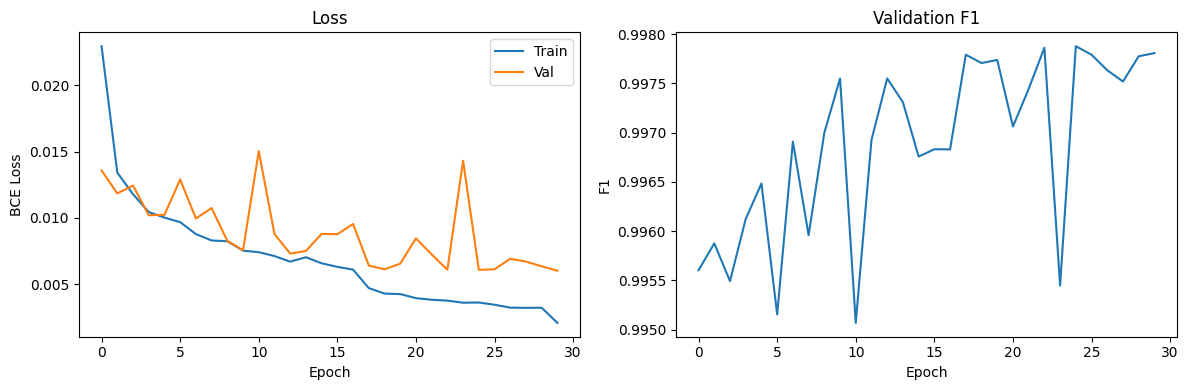

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history["train_loss"], label="Train")
axes[0].plot(history["val_loss"],   label="Val")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("BCE Loss")
axes[0].set_title("Loss")
axes[0].legend()

axes[1].plot(history["val_f1"])
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("F1")
axes[1].set_title("Validation F1")

plt.tight_layout()
plt.show()

## Evaluate on test set

In [21]:
model.load_state_dict(torch.load(CKPT_PATH, map_location=DEVICE))
model.eval()

test_probs, test_true = [], []
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        logits = model(X_batch.to(DEVICE))
        test_probs.append(torch.sigmoid(logits).cpu().numpy())
        test_true.append(y_batch.numpy())

test_probs = np.concatenate(test_probs)
test_true  = np.concatenate(test_true)
test_preds = (test_probs >= 0.5).astype(int)

## Metrics

In [22]:
print("=" * 50)
print("Test set metrics")
print("=" * 50)
print(classification_report(test_true, test_preds, target_names=["Noise", "Earthquake"], digits=4))
print(f"F1 (macro)   : {f1_score(test_true, test_preds, average='macro'):.4f}")
print(f"F1 (weighted): {f1_score(test_true, test_preds, average='weighted'):.4f}")
print(f"Accuracy     : {accuracy_score(test_true, test_preds):.4f}")
print(f"Precision    : {precision_score(test_true, test_preds):.4f}")
print(f"Recall       : {recall_score(test_true, test_preds):.4f}")
print(f"AUC-ROC      : {roc_auc_score(test_true, test_probs):.4f}")

Test set metrics
              precision    recall  f1-score   support

       Noise     0.9979    0.9985    0.9982     58588
  Earthquake     0.9982    0.9974    0.9978     48333

    accuracy                         0.9980    106921
   macro avg     0.9980    0.9979    0.9980    106921
weighted avg     0.9980    0.9980    0.9980    106921

F1 (macro)   : 0.9980
F1 (weighted): 0.9980
Accuracy     : 0.9980
Precision    : 0.9982
Recall       : 0.9974
AUC-ROC      : 0.9999


## Confusion matrix & ROC curve

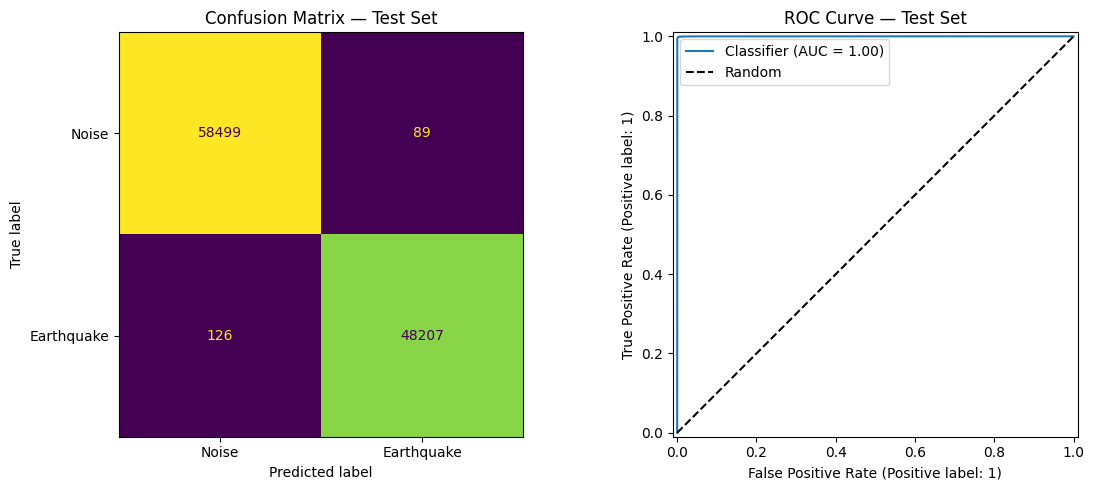

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay(
    confusion_matrix(test_true, test_preds),
    display_labels=["Noise", "Earthquake"],
).plot(ax=axes[0], colorbar=False)
axes[0].set_title("Confusion Matrix — Test Set")

RocCurveDisplay.from_predictions(test_true, test_probs, ax=axes[1])
axes[1].plot([0, 1], [0, 1], "k--", label="Random")
axes[1].set_title("ROC Curve — Test Set")
axes[1].legend()

plt.tight_layout()
plt.show()